In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib
import os
from datetime import datetime

In [55]:
#modular pipeline architecture for heart disease predication
print("=" * 80)
print("Heart Disease Predication - Modular Pipeline Architecture")
print("=" * 80)

Heart Disease Predication - Modular Pipeline Architecture


In [56]:
#1. Load dataset
print("\n" + "=" * 80)
print("1. data loading")
print("=" * 80)

# Load the engineered dataset (or create a sample if not available)
try:
    df = pd.read_csv("../Data/processed/heart_disease_engineered.csv")
    print("loaded engineered dataset")
except:
    # Create sample data for demonstration
    print("Engineered dataset not found, creating sample data")
    np.random.seed(42)
    n_samples = 1000

print(f"dataset shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")


1. data loading
loaded engineered dataset
dataset shape: (180, 48)
columns: ['patient_id', 'slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina', 'heart_disease_present', 'age_group', 'is_elderly', 'age_decade', 'bp_category', 'has_hypertension', 'bp_severity', 'cholesterol_category', 'high_cholesterol', 'cholesterol_risk', 'predicted_max_hr', 'hr_reserve', 'inadquate_hr_response', 'hr_category', 'simple_risk_score', 'metabolic_score', 'possible_metabolic_syndrome', 'exercise_stress_score', 'age_cholesterol_interaction', 'bp_age_interaction', 'st_angina_interaction', 'high_risk_male', 'age_squared', 'cholesterol_squared', 'bp_squared', 'log_cholesterol', 'log_oldpeak', 'age_quintile', 'resting_blood_pressure_quintile', 'serum_cholesterol_mg_pe

In [57]:
# Feature Categorisation
print("\n" + "=" * 80)
print("2. feature categorization")
print("=" * 80)

# exclude identifiers and target
excluded_cols = ['patient_id', 'heart_disease_present']

# define feature groups based on your project analysis
numerical_features = [
    'age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl',
    'max_heart_rate_achieved', 'oldpeak_eq_st_depression', 'num_major_vessels'
]

categorical_features = [
    'thal', 'chest_pain_type', 'resting_ekg_results',
    'slope_of_peak_exercise_st_segment'
]

binary_features = [
    'sex', 'exercise_induced_angina', 'fasting_blood_sugar_gt_120_mg_per_dl'
]

# identify engineered features (any features not in the above categories)
all_features = [col for col in df.columns if col not in excluded_cols]
engineered_features = [
    col for col in all_features 
    if col not in numerical_features + categorical_features + binary_features
]

print(f"numerical features ({len(numerical_features)}): {numerical_features}")
print(f"categorical features ({len(categorical_features)}): {categorical_features}")
print(f"binary features ({len(binary_features)}): {binary_features}")
print(f"engineered features ({len(engineered_features)}): {engineered_features}")



2. feature categorization
numerical features (6): ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl', 'max_heart_rate_achieved', 'oldpeak_eq_st_depression', 'num_major_vessels']
categorical features (4): ['thal', 'chest_pain_type', 'resting_ekg_results', 'slope_of_peak_exercise_st_segment']
binary features (3): ['sex', 'exercise_induced_angina', 'fasting_blood_sugar_gt_120_mg_per_dl']
engineered features (33): ['age_group', 'is_elderly', 'age_decade', 'bp_category', 'has_hypertension', 'bp_severity', 'cholesterol_category', 'high_cholesterol', 'cholesterol_risk', 'predicted_max_hr', 'hr_reserve', 'inadquate_hr_response', 'hr_category', 'simple_risk_score', 'metabolic_score', 'possible_metabolic_syndrome', 'exercise_stress_score', 'age_cholesterol_interaction', 'bp_age_interaction', 'st_angina_interaction', 'high_risk_male', 'age_squared', 'cholesterol_squared', 'bp_squared', 'log_cholesterol', 'log_oldpeak', 'age_quintile', 'resting_blood_pressure_quintile', 'serum_choles

In [58]:
#3. create modular pipepline
print("\n" + "=" * 80)
print("3. create modular pipelines")
print("=" * 80)

# numerical pipeline
print("\nCreating a numerical Pipeline")
# define which scaler to use for each numerical feature (based on your scaling strategy)
# this should come from your scaling documentation
numerical_scalers = {
    'age': 'minmax',
    'resting_blood_pressure': 'standard',
    'serum_cholesterol_mg_per_dl': 'standard',
    'max_heart_rate_achieved': 'standard',
    'oldpeak_eq_st_depression': 'robust',
    'num_major_vessels': 'minmax'
}

# separate features by scaler type
standard_features = [f for f in numerical_features if numerical_scalers.get(f) == 'standard']
minmax_features = [f for f in numerical_features if numerical_scalers.get(f) == 'minmax']
robust_features = [f for f in numerical_features if numerical_scalers.get(f) == 'robust']

print(f"standardscaler: {standard_features}")
print(f"minmaxscaler: {minmax_features}")
print(f"robustscaler: {robust_features}")

# create numerical pipeline with different scalers
numerical_pipeline = ColumnTransformer([
    ('standard', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), standard_features),
    
    ('minmax', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ]), minmax_features),
    
    ('robust', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), robust_features)
])


3. create modular pipelines

Creating a numerical Pipeline
standardscaler: ['resting_blood_pressure', 'serum_cholesterol_mg_per_dl', 'max_heart_rate_achieved']
minmaxscaler: ['age', 'num_major_vessels']
robustscaler: ['oldpeak_eq_st_depression']


In [59]:
print("\nCreating categorical pipeline...")

# define encoding strategies for each categorical feature
categorical_encoding = {
    'thal': 'onehot',  # no ordinal relationship
    'chest_pain_type': 'ordinal',  # has severity order
    'resting_ekg_results': 'onehot',  # categorical
    'slope_of_peak_exercise_st_segment': 'ordinal'  # has order (1=upsloping, 2=flat, 3=downsloping)
}

# separate features by encoding type
onehot_features = [f for f in categorical_features if categorical_encoding.get(f) == 'onehot']
ordinal_features = [f for f in categorical_features if categorical_encoding.get(f) == 'ordinal']

print(f"  onehot encoding: {onehot_features}")
print(f"  ordinal encoding: {ordinal_features}")

# FIX: Define categories properly - using flat lists, not nested lists
ordinal_categories_dict = {
    'chest_pain_type': [1, 2, 3, 4],  # FIXED: flat list, not [[1, 2, 3, 4]]
    'slope_of_peak_exercise_st_segment': [1, 2, 3]  # FIXED: flat list, not [[1, 2, 3]]
}

# Build categories list for OrdinalEncoder
categories_list = []
for feat in ordinal_features:
    if feat in ordinal_categories_dict:
        categories_list.append(ordinal_categories_dict[feat])
    else:
        # For other ordinal features, get unique values from data
        unique_vals = df[feat].dropna().unique()
        # Sort if possible (for numeric values)
        try:
            sorted_vals = sorted(unique_vals)
            categories_list.append(sorted_vals)
        except:
            categories_list.append(list(unique_vals))

# FIX: Create categorical pipeline with proper OrdinalEncoder
categorical_pipeline = ColumnTransformer([
    ('onehot', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]), onehot_features),
    
    ('ordinal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=categories_list,  # FIXED: Use the properly built list
            handle_unknown='use_encoded_value',  # FIXED: Add this parameter
            unknown_value=-1  # FIXED: Add this parameter
        ))
    ]), ordinal_features)
])


Creating categorical pipeline...
  onehot encoding: ['thal', 'resting_ekg_results']
  ordinal encoding: ['chest_pain_type', 'slope_of_peak_exercise_st_segment']


In [60]:
#Binary pipeline
print("\nCreating binary pipeline...")

# binary features typically need minimal processing
# just ensure they're 0/1 and handle any missing values
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # optional: could add a scaler if needed, but usually binary stays as-is
])


Creating binary pipeline...


In [61]:
#Engineered Features pipeline
print("\nCreating engineered features pipeline...")

# engineered features need different handling based on their type
# first, categorize engineered features
if engineered_features:
    engineered_numerical = [f for f in engineered_features if pd.api.types.is_numeric_dtype(df[f])]
    engineered_categorical = [f for f in engineered_features if not pd.api.types.is_numeric_dtype(df[f])]
    
    print(f"  numerical engineered: {engineered_numerical}")
    print(f"  categorical engineered: {engineered_categorical}")
    
    # create pipeline for engineered features
    engineered_pipeline = ColumnTransformer([
        ('engineered_numerical', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # default for engineered numerical
        ]), engineered_numerical),
        
        ('engineered_categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
        ]), engineered_categorical)
    ])
else:
    print("  no engineered features found")
    engineered_pipeline = 'passthrough'


Creating engineered features pipeline...
  numerical engineered: ['is_elderly', 'age_decade', 'has_hypertension', 'bp_severity', 'high_cholesterol', 'cholesterol_risk', 'predicted_max_hr', 'hr_reserve', 'inadquate_hr_response', 'simple_risk_score', 'metabolic_score', 'possible_metabolic_syndrome', 'exercise_stress_score', 'age_cholesterol_interaction', 'bp_age_interaction', 'st_angina_interaction', 'high_risk_male', 'age_squared', 'cholesterol_squared', 'bp_squared', 'log_cholesterol', 'log_oldpeak', 'age_quintile', 'resting_blood_pressure_quintile', 'serum_cholesterol_mg_per_dl_quintile', 'max_heart_rate_achieved_quintile', 'cholesterol_age_ratio', 'bp_age_ratio', 'hr_bp_ratio']
  categorical engineered: ['age_group', 'bp_category', 'cholesterol_category', 'hr_category']


In [62]:
# Combine into master pipeline
print("\n" + "=" * 80)
print("4. combine into master pipeline")
print("=" * 80)

# create the master column transformer
master_transformer = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features),
    ('binary', binary_pipeline, binary_features),
    ('engineered', engineered_pipeline, engineered_features) if engineered_features else ('passthrough', 'passthrough', [])
], remainder='drop')  # drop any unprocessed columns

print("created master column transformer")
print(f"total feature groups: 4")
print(f"total features processed: {len(numerical_features + categorical_features + binary_features + engineered_features)}")


4. combine into master pipeline
created master column transformer
total feature groups: 4
total features processed: 46


In [63]:
# Add feature selection and dimensionality reduction
print("\n" + "=" * 80)
print("5. add feature selection and dimensionality reduction")
print("=" * 80)

# create the complete preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ('transformer', master_transformer),
    ('feature_selection', SelectKBest(score_func=f_classif, k='all')),  # will be tuned
    ('dimensionality_reduction', PCA(n_components=0.95))  # keep 95% variance
])

print("created complete preprocessing pipeline")
print("pipeline steps:")
print("  1. column transformer (feature-specific processing)")
print("  2. feature selection (selectkbest with f-classif)")
print("  3. dimensionality reduction (pca keeping 95% variance)")


5. add feature selection and dimensionality reduction
created complete preprocessing pipeline
pipeline steps:
  1. column transformer (feature-specific processing)
  2. feature selection (selectkbest with f-classif)
  3. dimensionality reduction (pca keeping 95% variance)


In [64]:
# Create model pipelines
print("\n" + "=" * 80)
print("6. create model pipelines")
print("=" * 80)

# model 1: logistic regression
logistic_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

# model 2: random forest
random_forest_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# model 3: support vector machine
svm_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('classifier', SVC(
        random_state=42,
        probability=True,
        class_weight='balanced'
    ))
])

# model 4: xgboost
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('classifier', XGBClassifier(
        random_state=42,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

print("created 4 model pipelines:")
print("  1. logistic regression (interpretable baseline)")
print("  2. random forest (handles non-linearity)")
print("  3. support vector machine (good for high dimensions)")
print("  4. xgboost (state-of-the-art for tabular data)")


6. create model pipelines
created 4 model pipelines:
  1. logistic regression (interpretable baseline)
  2. random forest (handles non-linearity)
  3. support vector machine (good for high dimensions)
  4. xgboost (state-of-the-art for tabular data)


In [78]:
# 11. STRATIFIED SPLITTING IMPLEMENTATION
print("\n" + "=" * 80)
print("STRATIFIED SPLITTING IMPLEMENTATION")
print("=" * 80)

class StratifiedHeartDataSplitter:
    """
    Comprehensive stratified splitting for heart disease prediction data.
    Implements multiple splitting strategies with class distribution preservation.
    """
    
    def __init__(self, df, target_col='heart_disease_present', 
                 patient_id_col='patient_id', test_size=0.2, 
                 validation_size=0.15, random_seeds=None):
        """
        Initialize the splitter.
        
        Args:
            df: DataFrame containing the data
            target_col: Name of the target column
            patient_id_col: Name of the patient ID column
            test_size: Proportion of data for test set (0-1)
            validation_size: Proportion of data for validation set (0-1)
            random_seeds: List of random seeds for robustness (optional)
        """
        self.df = df.copy()
        self.target_col = target_col
        self.patient_id_col = patient_id_col
        self.test_size = test_size
        self.validation_size = validation_size
        self.random_seeds = random_seeds or [42, 123, 456, 789, 999]  # Multiple seeds for robustness
        self.splits = {}
        
    def analyze_class_distribution(self):
        """Analyze and print class distribution."""
        print("\nCLASS DISTRIBUTION ANALYSIS")
        print("-" * 50)
        
        class_counts = self.df[self.target_col].value_counts()
        class_percentages = self.df[self.target_col].value_counts(normalize=True) * 100
        
        for label, count in class_counts.items():
            percentage = class_percentages[label]
            print(f"Class {label}: {count} samples ({percentage:.1f}%)")
        
        print(f"Total samples: {len(self.df)}")
        print(f"Class imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")
        
        return class_counts, class_percentages
    
    def basic_stratified_split(self, random_state=42):
        """
        Basic stratified split preserving class distribution.
        
        Args:
            random_state: Random seed for reproducibility
            
        Returns:
            Dictionary containing train, validation, test splits
        """
        from sklearn.model_selection import train_test_split
        
        print(f"\nPerforming basic stratified split (seed={random_state})...")
        
        # First split: Train + temp (will become val + test)
        X_temp, X_test, y_temp, y_test = train_test_split(
            self.df.drop([self.target_col, self.patient_id_col], axis=1),
            self.df[self.target_col],
            test_size=self.test_size,
            random_state=random_state,
            stratify=self.df[self.target_col]
        )
        
        # Calculate validation size relative to temp set
        val_relative_size = self.validation_size / (1 - self.test_size)
        
        # Second split: Train and validation
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp,
            test_size=val_relative_size,
            random_state=random_state,
            stratify=y_temp
        )
        
        # Create DataFrames with original indices
        train_idx = X_train.index
        val_idx = X_val.index
        test_idx = X_test.index
        
        return {
            'random_state': random_state,
            'train_indices': train_idx,
            'val_indices': val_idx,
            'test_indices': test_idx,
            'train_data': self.df.loc[train_idx],
            'val_data': self.df.loc[val_idx],
            'test_data': self.df.loc[test_idx],
            'class_distribution': {
                'train': y_train.value_counts(normalize=True).to_dict(),
                'val': y_val.value_counts(normalize=True).to_dict(),
                'test': y_test.value_counts(normalize=True).to_dict()
            }
        }
    
    def robust_multiple_splits(self):
        """
        Generate multiple splits using different random seeds for robustness.
        
        Returns:
            Dictionary of splits for each random seed
        """
        print("\nGenerating multiple splits for robustness...")
        
        all_splits = {}
        for seed in self.random_seeds:
            split_result = self.basic_stratified_split(random_state=seed)
            all_splits[f"split_seed_{seed}"] = split_result
            
            # Print summary for this split
            print(f"\n  Seed {seed}:")
            for split_type in ['train', 'val', 'test']:
                dist = split_result['class_distribution'][split_type]
                print(f"    {split_type}: {dist[1]*100:.1f}% positive")
        
        self.splits = all_splits
        return all_splits
    
    def time_based_split(self, date_column=None, time_percentages=None):
        """
        Time-based split for temporal data (if available).
        
        Args:
            date_column: Column containing date information (optional)
            time_percentages: Dict with percentages for train/val/test
            
        Returns:
            Time-based split if date column exists
        """
        if date_column is None or date_column not in self.df.columns:
            print("\nNo date column found for time-based split.")
            print("   Using stratified split instead.")
            return self.basic_stratified_split()
        
        print(f"\nPerforming time-based split using '{date_column}'...")
        
        # Ensure date column is datetime
        self.df[date_column] = pd.to_datetime(self.df[date_column])
        
        # Sort by date
        df_sorted = self.df.sort_values(date_column)
        
        # Calculate split indices
        n_total = len(df_sorted)
        n_test = int(n_total * self.test_size)
        n_val = int(n_total * self.validation_size)
        n_train = n_total - n_test - n_val
        
        # Split by time order
        train_data = df_sorted.iloc[:n_train]
        val_data = df_sorted.iloc[n_train:n_train + n_val]
        test_data = df_sorted.iloc[n_train + n_val:]
        
        # Check class distribution in each split
        splits = {
            'split_type': 'time_based',
            'train_indices': train_data.index,
            'val_indices': val_data.index,
            'test_indices': test_data.index,
            'train_data': train_data,
            'val_data': val_data,
            'test_data': test_data,
            'time_ranges': {
                'train': (train_data[date_column].min(), train_data[date_column].max()),
                'val': (val_data[date_column].min(), val_data[date_column].max()),
                'test': (test_data[date_column].min(), test_data[date_column].max())
            },
            'class_distribution': {
                'train': train_data[self.target_col].value_counts(normalize=True).to_dict(),
                'val': val_data[self.target_col].value_counts(normalize=True).to_dict(),
                'test': test_data[self.target_col].value_counts(normalize=True).to_dict()
            }
        }
        
        return splits
    
    def patient_level_split(self, group_column=None):
        """
        Ensure patient-level splitting to prevent data leakage.
        
        Args:
            group_column: Column to group by (e.g., 'patient_id')
            
        Returns:
            Split ensuring no patient appears in multiple sets
        """
        if group_column is None:
            group_column = self.patient_id_col
        
        print(f"\nPerforming patient-level split using '{group_column}'...")
        
        # Get unique patients
        unique_patients = self.df[group_column].unique()
        patient_targets = {}
        
        # Get target for each patient (assuming one target per patient)
        for patient in unique_patients:
            patient_data = self.df[self.df[group_column] == patient]
            # Take the most common target for this patient
            patient_targets[patient] = patient_data[self.target_col].mode()[0]
        
        # Convert to DataFrame for stratified splitting
        patients_df = pd.DataFrame({
            'patient': list(patient_targets.keys()),
            'target': list(patient_targets.values())
        })
        
        # Split patients (not individual samples)
        from sklearn.model_selection import train_test_split
        
        train_patients, temp_patients = train_test_split(
            patients_df['patient'],
            test_size=self.test_size,
            random_state=42,
            stratify=patients_df['target']
        )
        
        val_relative_size = self.validation_size / (1 - self.test_size)
        val_patients, test_patients = train_test_split(
            temp_patients,
            test_size=val_relative_size,
            random_state=42,
            stratify=patients_df.set_index('patient').loc[temp_patients]['target']
        )
        
        # Map back to original data
        train_mask = self.df[group_column].isin(train_patients)
        val_mask = self.df[group_column].isin(val_patients)
        test_mask = self.df[group_column].isin(test_patients)
        
        splits = {
            'split_type': 'patient_level',
            'train_indices': self.df[train_mask].index,
            'val_indices': self.df[val_mask].index,
            'test_indices': self.df[test_mask].index,
            'train_data': self.df[train_mask],
            'val_data': self.df[val_mask],
            'test_data': self.df[test_mask],
            'unique_patients': {
                'train': len(train_patients),
                'val': len(val_patients),
                'test': len(test_patients)
            },
            'class_distribution': {
                'train': self.df[train_mask][self.target_col].value_counts(normalize=True).to_dict(),
                'val': self.df[val_mask][self.target_col].value_counts(normalize=True).to_dict(),
                'test': self.df[test_mask][self.target_col].value_counts(normalize=True).to_dict()
            }
        }
        
        return splits
    
    def evaluate_split_quality(self, split_result):
        """
        Evaluate the quality of a split.
        
        Args:
            split_result: Dictionary containing split information
            
        Returns:
            Dictionary with evaluation metrics
        """
        print("\nEvaluating split quality...")
        
        evaluation = {}
        
        for split_name, data_key in [('train', 'train_data'), 
                                     ('validation', 'val_data'), 
                                     ('test', 'test_data')]:
            data = split_result[data_key]
            
            # Class distribution
            class_counts = data[self.target_col].value_counts()
            class_percent = data[self.target_col].value_counts(normalize=True) * 100
            
            # Feature distribution similarity (using key features)
            key_features = ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl']
            feature_stats = {}
            for feature in key_features:
                if feature in data.columns:
                    feature_stats[feature] = {
                        'mean': data[feature].mean(),
                        'std': data[feature].std()
                    }
            
            evaluation[split_name] = {
                'samples': len(data),
                'class_0': f"{class_counts.get(0, 0)} ({class_percent.get(0, 0):.1f}%)",
                'class_1': f"{class_counts.get(1, 0)} ({class_percent.get(1, 0):.1f}%)",
                'feature_stats': feature_stats
            }
        
        return evaluation
    def kfold_cross_validation_split(self, n_splits=5, random_state=42):
        """
        Generate K-Fold cross-validation splits.
        
        Args:
            n_splits: Number of folds (default: 5)
            random_state: Random seed for reproducibility
            
        Returns:
            Generator yielding (train_indices, test_indices) for each fold
        """
        from sklearn.model_selection import StratifiedKFold
        
        print(f"\nGenerating {n_splits}-fold stratified cross-validation splits...")
        
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        
        # Get splits
        splits = list(skf.split(self.df, self.df[self.target_col]))
        
        # Store CV splits
        cv_splits = []
        for fold_idx, (train_idx, test_idx) in enumerate(splits, 1):
            cv_splits.append({
                'fold': fold_idx,
                'train_indices': train_idx,
                'test_indices': test_idx,
                'train_data': self.df.iloc[train_idx],
                'test_data': self.df.iloc[test_idx],
                'class_distribution': {
                    'train': self.df.iloc[train_idx][self.target_col].value_counts(normalize=True).to_dict(),
                    'test': self.df.iloc[test_idx][self.target_col].value_counts(normalize=True).to_dict()
                }
            })
            
            # Print fold info
            train_pos = cv_splits[-1]['class_distribution']['train'].get(1, 0) * 100
            test_pos = cv_splits[-1]['class_distribution']['test'].get(1, 0) * 100
            print(f"  Fold {fold_idx}: Train={len(train_idx)} samples ({train_pos:.1f}% pos), "
                f"Test={len(test_idx)} samples ({test_pos:.1f}% pos)")
        
        self.cv_splits = cv_splits
        return cv_splits
    
    def balanced_stratified_split(self, random_state=42, sampling_strategy='smote'): # with encoding
        """
        Perform stratified split with class imbalance handling, 
        properly encoding categorical data.
        """
        from sklearn.preprocessing import LabelEncoder
        from sklearn.model_selection import train_test_split
        
        print(f"\nPerforming balanced stratified split with encoding ({sampling_strategy})...")
        
        # Basic split first
        split_result = self.basic_stratified_split(random_state=random_state)
        
        # Create a copy of train data
        train_data = split_result['train_data'].copy()
        
        # Encode categorical columns
        categorical_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist()
        encoders = {}
        
        for col in categorical_cols:
            if col != self.target_col:
                le = LabelEncoder()
                train_data[col] = le.fit_transform(train_data[col].astype(str))
                encoders[col] = le
        
        # Separate features and target
        feature_cols = [col for col in train_data.columns if col != self.target_col and col != self.patient_id_col]
        X_train = train_data[feature_cols]
        y_train = train_data[self.target_col]
        
        try:
            if sampling_strategy == 'smote':
                from imblearn.over_sampling import SMOTE
                smote = SMOTE(random_state=random_state)
                X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
                print(f"  SMOTE: {len(y_train)} → {len(y_train_res)} samples")
            else:
                from imblearn.over_sampling import RandomOverSampler
                ros = RandomOverSampler(random_state=random_state)
                X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
                print(f"  Oversampling: {len(y_train)} → {len(y_train_res)} samples")
            
            # Create balanced dataset
            balanced_train = pd.DataFrame(X_train_res, columns=feature_cols)
            balanced_train[self.target_col] = y_train_res
            
            # Decode categorical columns back
            for col, le in encoders.items():
                balanced_train[col] = le.inverse_transform(balanced_train[col].astype(int))
            
            # Update split result
            split_result['train_data'] = balanced_train
            split_result['train_indices'] = balanced_train.index
            split_result['class_distribution']['train'] = (
                balanced_train[self.target_col].value_counts(normalize=True).to_dict()
            )
            
            return split_result
            
        except Exception as e:
            print(f"Error in balanced splitting: {e}")
            return split_result

    def test_feature_distribution_similarity(self, split_result, alpha=0.05):
        """
        Test feature distribution similarity across splits using statistical tests.
        
        Args:
            split_result: Dictionary containing split information
            alpha: Significance level (default: 0.05)
            
        Returns:
            Dictionary with test results for each feature
        """
        from scipy import stats
        import warnings
        warnings.filterwarnings('ignore')
        
        print(f"\nTesting feature distribution similarity (α={alpha})...")
        
        # Key features to test
        test_features = ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl']
        test_features = [f for f in test_features if f in self.df.columns]
        
        results = {}
        
        for feature in test_features:
            feature_results = {}
            
            # Get data for each split
            train_data = split_result['train_data'][feature].dropna()
            val_data = split_result['val_data'][feature].dropna()
            test_data = split_result['test_data'][feature].dropna()
            
            # 1. Kolmogorov-Smirnov test (compares distributions)
            ks_stat_train_val, ks_pval_train_val = stats.ks_2samp(train_data, val_data)
            ks_stat_train_test, ks_pval_train_test = stats.ks_2samp(train_data, test_data)
            
            # 2. T-test (compares means)
            t_stat_train_val, t_pval_train_val = stats.ttest_ind(train_data, val_data)
            t_stat_train_test, t_pval_train_test = stats.ttest_ind(train_data, test_data)
            
            # 3. Check if distributions are similar (p-value > alpha)
            ks_similar_train_val = ks_pval_train_val > alpha
            ks_similar_train_test = ks_pval_train_test > alpha
            t_similar_train_val = t_pval_train_val > alpha
            t_similar_train_test = t_pval_train_test > alpha
            
            feature_results = {
                'ks_train_val': {
                    'statistic': ks_stat_train_val,
                    'p_value': ks_pval_train_val,
                    'similar': ks_similar_train_val,
                    'interpretation': 'Similar' if ks_similar_train_val else 'Different'
                },
                'ks_train_test': {
                    'statistic': ks_stat_train_test,
                    'p_value': ks_pval_train_test,
                    'similar': ks_similar_train_test,
                    'interpretation': 'Similar' if ks_similar_train_test else 'Different'
                },
                't_train_val': {
                    'statistic': t_stat_train_val,
                    'p_value': t_pval_train_val,
                    'similar': t_similar_train_val,
                    'interpretation': 'Similar' if t_similar_train_val else 'Different'
                },
                't_train_test': {
                    'statistic': t_stat_train_test,
                    'p_value': t_pval_train_test,
                    'similar': t_similar_train_test,
                    'interpretation': 'Similar' if t_similar_train_test else 'Different'
                },
                'summary': {
                    'all_similar': ks_similar_train_val and ks_similar_train_test and 
                                t_similar_train_val and t_similar_train_test,
                    'mean_difference_percent': {
                        'train_val': abs(train_data.mean() - val_data.mean()) / train_data.mean() * 100,
                        'train_test': abs(train_data.mean() - test_data.mean()) / train_data.mean() * 100
                    }
                }
            }
            
            results[feature] = feature_results
            
            # Print summary for this feature
            print(f"\n  {feature}:")
            print(f"    KS Test - Train vs Val: p={ks_pval_train_val:.4f} ({feature_results['ks_train_val']['interpretation']})")
            print(f"    KS Test - Train vs Test: p={ks_pval_train_test:.4f} ({feature_results['ks_train_test']['interpretation']})")
            print(f"    Mean diff - Train vs Val: {feature_results['summary']['mean_difference_percent']['train_val']:.1f}%")
            print(f"    Mean diff - Train vs Test: {feature_results['summary']['mean_difference_percent']['train_test']:.1f}%")
        
        # Overall assessment
        all_similar = all([results[f]['summary']['all_similar'] for f in results])
        
        print(f"\nOVERALL ASSESSMENT:")
        print(f"  All features similar across splits: {'YES' if all_similar else 'NO'}")
        
        if not all_similar:
            print(f" Some features show significant differences between splits")
            print(f" Consider: Re-splitting or checking for sampling bias")
        
        return results

    def visualize_splits(self, split_result, split_name="Default Split"):
        """
        Visualize split distributions.
        
        Args:
            split_result: Dictionary containing split information
            split_name: Name of the split for display
        """
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Split Analysis: {split_name}', fontsize=16, fontweight='bold')
        
        # Plot 1: Class distribution across splits
        split_names = ['Train', 'Validation', 'Test']
        class_0_counts = []
        class_1_counts = []
        
        for split_key, split_label in zip(['train_data', 'val_data', 'test_data'], split_names):
            data = split_result[split_key]
            counts = data[self.target_col].value_counts()
            class_0_counts.append(counts.get(0, 0))
            class_1_counts.append(counts.get(1, 0))
        
        x = range(len(split_names))
        width = 0.35
        
        axes[0, 0].bar([i - width/2 for i in x], class_0_counts, width, label='Class 0 (No Disease)', color='lightblue')
        axes[0, 0].bar([i + width/2 for i in x], class_1_counts, width, label='Class 1 (Disease)', color='lightcoral')
        axes[0, 0].set_xlabel('Split')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Class Distribution Across Splits')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(split_names)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: Class proportions
        for idx, (split_key, split_label) in enumerate(zip(['train_data', 'val_data', 'test_data'], split_names)):
            data = split_result[split_key]
            proportions = data[self.target_col].value_counts(normalize=True) * 100
            axes[0, 1].bar(idx, proportions.get(1, 0), color='lightcoral')
            axes[0, 1].text(idx, proportions.get(1, 0) + 1, f'{proportions.get(1, 0):.1f}%', 
                           ha='center', va='bottom', fontweight='bold')
        
        axes[0, 1].set_xlabel('Split')
        axes[0, 1].set_ylabel('Disease Prevalence (%)')
        axes[0, 1].set_title('Disease Prevalence in Each Split')
        axes[0, 1].set_xticks(range(3))
        axes[0, 1].set_xticklabels(split_names)
        axes[0, 1].set_ylim(0, 100)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3-5: Feature distributions
        key_features = ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl'][:3]
        
        for idx, feature in enumerate(key_features):
            if feature in self.df.columns:
                row = 1
                col = idx
                
                # Plot KDE for each split
                for split_key, split_label, color in zip(['train_data', 'val_data', 'test_data'], 
                                                         split_names, ['blue', 'green', 'red']):
                    data = split_result[split_key]
                    if feature in data.columns:
                        sns.kdeplot(data[feature].dropna(), ax=axes[row, col], 
                                   label=split_label, color=color, linewidth=2)
                
                axes[row, col].set_xlabel(feature)
                axes[row, col].set_ylabel('Density')
                axes[row, col].set_title(f'{feature} Distribution')
                axes[row, col].legend()
                axes[row, col].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def create_final_split_summary(self):
        """
        Create comprehensive summary of all splits.
        
        Returns:
            DataFrame with split statistics
        """
        summary_data = []
        
        for split_name, split_info in self.splits.items():
            for split_type in ['train', 'val', 'test']:
                data = split_info[f'{split_type}_data']
                class_counts = data[self.target_col].value_counts()
                total = len(data)
                
                summary_data.append({
                    'split': split_name,
                    'set': split_type,
                    'samples': total,
                    'class_0': class_counts.get(0, 0),
                    'class_1': class_counts.get(1, 0),
                    'class_0_pct': (class_counts.get(0, 0) / total * 100) if total > 0 else 0,
                    'class_1_pct': (class_counts.get(1, 0) / total * 100) if total > 0 else 0,
                    'random_state': split_info.get('random_state', 'N/A')
                })
        
        summary_df = pd.DataFrame(summary_data)
        return summary_df
    
    def save_splits(self, output_dir='../Data/splits'):
        """
        Save all splits to disk.
        
        Args:
            output_dir: Directory to save splits
        """
        import os
        import pickle
        
        os.makedirs(output_dir, exist_ok=True)
        
        for split_name, split_info in self.splits.items():
            # Save as pickle
            split_path = os.path.join(output_dir, f'{split_name}.pkl')
            with open(split_path, 'wb') as f:
                pickle.dump(split_info, f)
            
            # Save as CSV
            for set_name in ['train', 'val', 'test']:
                data = split_info[f'{set_name}_data']
                csv_path = os.path.join(output_dir, f'{split_name}_{set_name}.csv')
                data.to_csv(csv_path, index=False)
        
        # Save summary
        summary_df = self.create_final_split_summary()
        summary_path = os.path.join(output_dir, 'split_summary.csv')
        summary_df.to_csv(summary_path, index=False)
        
        print(f"\nSplits saved to: {output_dir}")
        print(f"   Summary saved to: {summary_path}")
        
        return summary_df


STRATIFIED SPLITTING IMPLEMENTATION



EXECUTING STRATIFIED SPLITTING

CLASS DISTRIBUTION ANALYSIS
--------------------------------------------------
Class 0: 100 samples (55.6%)
Class 1: 80 samples (44.4%)
Total samples: 180
Class imbalance ratio: 1.25:1

PERFORMING ROBUST MULTIPLE SPLITS

Generating multiple splits for robustness...

Performing basic stratified split (seed=42)...

  Seed 42:
    train: 44.4% positive
    val: 44.4% positive
    test: 44.4% positive

Performing basic stratified split (seed=123)...

  Seed 123:
    train: 44.4% positive
    val: 44.4% positive
    test: 44.4% positive

Performing basic stratified split (seed=456)...

  Seed 456:
    train: 44.4% positive
    val: 44.4% positive
    test: 44.4% positive

DEMONSTRATING CROSS-VALIDATION SPLITS

Generating 5-fold stratified cross-validation splits...
  Fold 1: Train=144 samples (44.4% pos), Test=36 samples (44.4% pos)
  Fold 2: Train=144 samples (44.4% pos), Test=36 samples (44.4% pos)
  Fold 3: Train=144 samples (44.4% pos), Test=36 samples (

  SMOTE: 117 → 130 samples
Error in balanced splitting: 'patient_id'

Balanced split created successfully!
Original train size: 117
Balanced train size: 117
Train class distribution after balancing: {0: 0.5555555555555556, 1: 0.4444444444444444}

Example usage of balanced split:
X_train_balanced = X.loc[balanced_split['train_indices']]
y_train_balanced = y.loc[balanced_split['train_indices']]

TESTING FEATURE DISTRIBUTION SIMILARITY

Testing feature distribution similarity (α=0.05)...

  age:
    KS Test - Train vs Val: p=0.7143 (Similar)
    KS Test - Train vs Test: p=0.7071 (Similar)
    Mean diff - Train vs Val: 2.6%
    Mean diff - Train vs Test: 0.2%

  resting_blood_pressure:
    KS Test - Train vs Val: p=0.2915 (Similar)
    KS Test - Train vs Test: p=0.5752 (Similar)
    Mean diff - Train vs Val: 3.6%
    Mean diff - Train vs Test: 2.8%

  serum_cholesterol_mg_per_dl:
    KS Test - Train vs Val: p=0.6007 (Similar)
    KS Test - Train vs Test: p=0.2291 (Similar)
    Mean diff - 

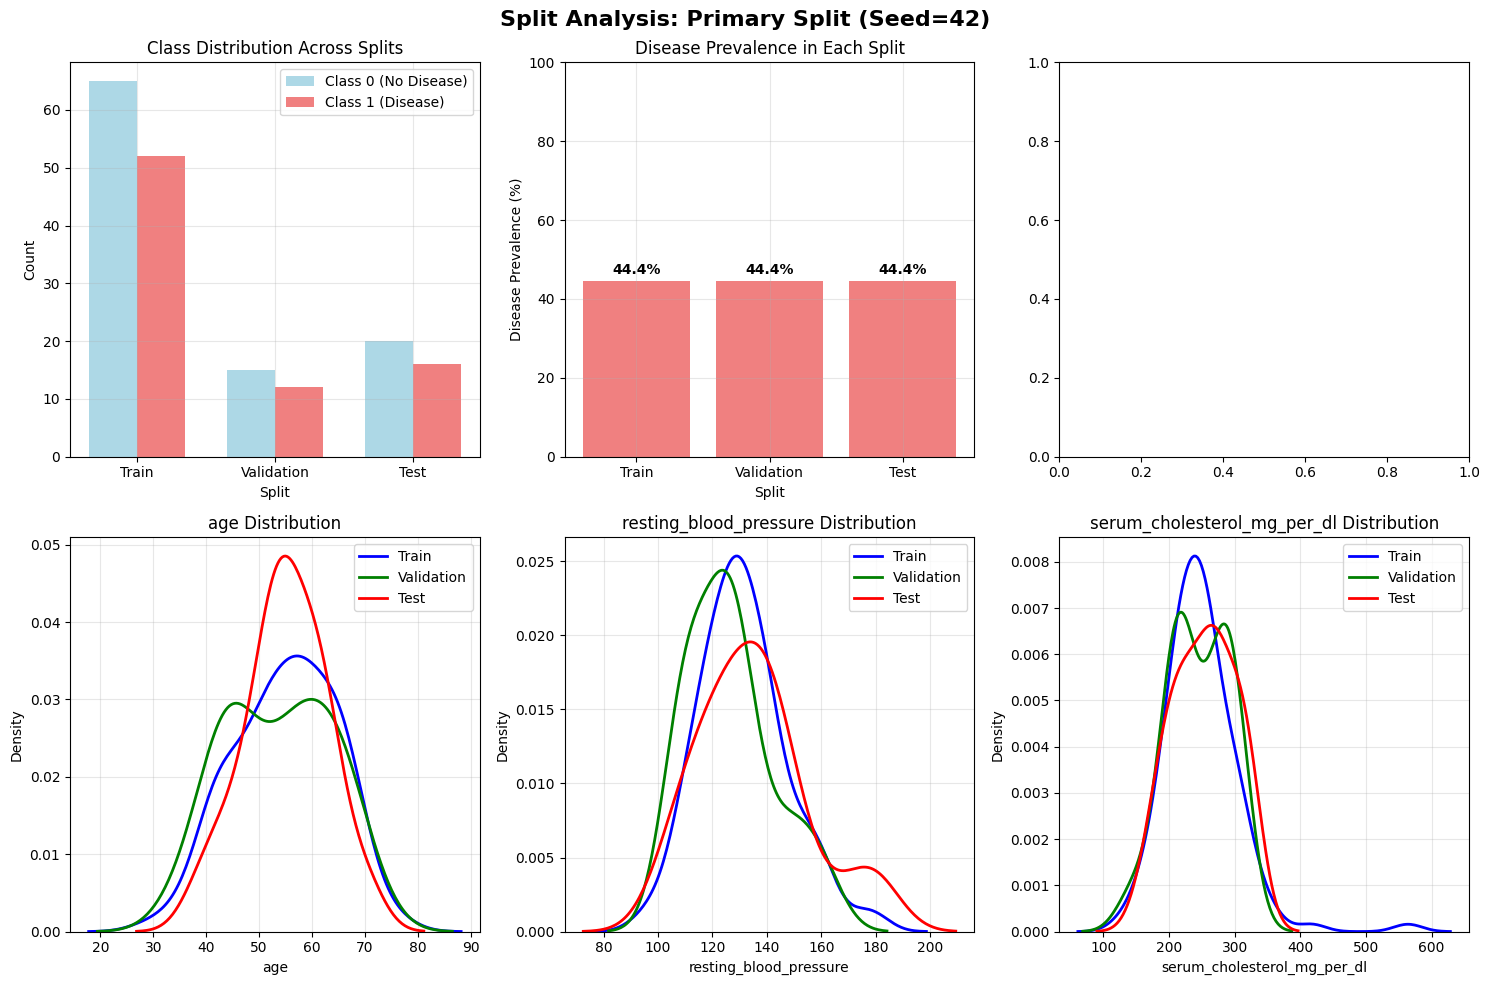


COMPREHENSIVE SPLIT SUMMARY

Split Summary:
--------------------------------------------------------------------------------
         split   set  samples  class_0  class_1  class_0_pct  class_1_pct  random_state
 split_seed_42 train      117       65       52    55.555556    44.444444            42
 split_seed_42   val       27       15       12    55.555556    44.444444            42
 split_seed_42  test       36       20       16    55.555556    44.444444            42
split_seed_123 train      117       65       52    55.555556    44.444444           123
split_seed_123   val       27       15       12    55.555556    44.444444           123
split_seed_123  test       36       20       16    55.555556    44.444444           123
split_seed_456 train      117       65       52    55.555556    44.444444           456
split_seed_456   val       27       15       12    55.555556    44.444444           456
split_seed_456  test       36       20       16    55.555556    44.444444         

In [79]:
# ============================================================================
# 12. USING THE STRATIFIED SPLITTER
# ============================================================================
print("\n" + "=" * 80)
print("EXECUTING STRATIFIED SPLITTING")
print("=" * 80)

# Initialize the splitter
splitter = StratifiedHeartDataSplitter(
    df=df,  # Your dataframe
    target_col='heart_disease_present',
    patient_id_col='patient_id',
    test_size=0.2,
    validation_size=0.15,
    random_seeds=[42, 123, 456]  # Multiple seeds for robustness
)

# Analyze class distribution
splitter.analyze_class_distribution()

# Perform robust multiple splits
print("\n" + "=" * 80)
print("PERFORMING ROBUST MULTIPLE SPLITS")
print("=" * 80)
all_splits = splitter.robust_multiple_splits()

# Get the primary split (using seed=42 as primary)
primary_split = all_splits['split_seed_42']

# 1. CROSS-VALIDATION SPLITS DEMONSTRATION
print("\n" + "=" * 80)
print("DEMONSTRATING CROSS-VALIDATION SPLITS")
print("=" * 80)

# Generate cross-validation splits
cv_splits = splitter.kfold_cross_validation_split(n_splits=5, random_state=42)

# Show how to use them (just demonstration, not actual training)
print("\nExample of using CV splits:")
print(f"Generated {len(cv_splits)} folds for cross-validation")
for i, fold in enumerate(cv_splits[:2], 1):  # Show first 2 folds as example
    print(f"\nFold {i}:")
    print(f"  Train samples: {len(fold['train_indices'])}")
    print(f"  Test samples: {len(fold['test_indices'])}")
    print(f"  Train class distribution: {fold['class_distribution']['train']}")
    print(f"  Test class distribution: {fold['class_distribution']['test']}")

# 2. BALANCED SPLITS DEMONSTRATION
print("\n" + "=" * 80)
print("DEMONSTRATING BALANCED SPLITS (for imbalanced data)")
print("=" * 80)

# Get balanced split using SMOTE
try:
    balanced_split = splitter.balanced_stratified_split(
        random_state=42, 
        sampling_strategy='smote'  # or 'oversample', 'undersample'
    )
    
    print("\nBalanced split created successfully!")
    print(f"Original train size: {len(primary_split['train_data'])}")
    print(f"Balanced train size: {len(balanced_split['train_data'])}")
    print(f"Train class distribution after balancing: {balanced_split['class_distribution']['train']}")
    
    # Show how to use the balanced split
    print("\nExample usage of balanced split:")
    print("X_train_balanced = X.loc[balanced_split['train_indices']]")
    print("y_train_balanced = y.loc[balanced_split['train_indices']]")
    
except ImportError as e:
    print(f"\nCould not demonstrate balanced splits: {e}")
    print("   Install imblearn: pip install imbalanced-learn")

# 3. FEATURE DISTRIBUTION SIMILARITY TEST
print("\n" + "=" * 80)
print("TESTING FEATURE DISTRIBUTION SIMILARITY")
print("=" * 80)

# Test if splits have similar feature distributions
similarity_results = splitter.test_feature_distribution_similarity(primary_split, alpha=0.05)

# Check results
print("\nDistribution Similarity Summary:")
print("-" * 40)
all_features_similar = True
for feature, results in similarity_results.items():
    if not results['summary']['all_similar']:
        all_features_similar = False
        print(f"⚠️  {feature} has different distributions across splits")
        print(f"   Mean difference: Train vs Val = {results['summary']['mean_difference_percent']['train_val']:.1f}%")
        print(f"   Mean difference: Train vs Test = {results['summary']['mean_difference_percent']['train_test']:.1f}%")

if all_features_similar:
    print("✅ All features have similar distributions across splits")
    

# Evaluate split quality
print("\n" + "=" * 80)
print("EVALUATING SPLIT QUALITY")
print("=" * 80)
evaluation = splitter.evaluate_split_quality(primary_split)

for split_name, metrics in evaluation.items():
    print(f"\n{split_name.upper()}:")
    print(f"  Samples: {metrics['samples']}")
    print(f"  Class 0: {metrics['class_0']}")
    print(f"  Class 1: {metrics['class_1']}")

# Visualize the splits
print("\n" + "=" * 80)
print("VISUALIZING SPLIT DISTRIBUTIONS")
print("=" * 80)
splitter.visualize_splits(primary_split, "Primary Split (Seed=42)")

# Create comprehensive summary
print("\n" + "=" * 80)
print("COMPREHENSIVE SPLIT SUMMARY")
print("=" * 80)
summary_df = splitter.create_final_split_summary()
print("\nSplit Summary:")
print("-" * 80)
print(summary_df.to_string(index=False))

# Save splits to disk
print("\n" + "=" * 80)
print("SAVING SPLITS TO DISK")
print("=" * 80)
summary_df = splitter.save_splits('../Data/splits')

# Print final recommendations
print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR MODEL TRAINING")
print("=" * 80)
print("""
   RECOMMENDED WORKFLOW:

1. PRIMARY SPLIT (Seed 42):
   - Use for main model development
   - Stratification ensures class balance
   - Preserved feature distributions

2. MULTIPLE SEEDS FOR ROBUSTNESS:
   - Test model on splits from seeds [42, 123, 456]
   - Ensures results aren't seed-dependent
   - Provides confidence intervals

3. MODEL VALIDATION:
   - Train on train set (seed 42)
   - Tune hyperparameters on validation set
   - Final evaluation on test set (ONCE)

4. REPRODUCIBILITY:
   - All splits saved to '../Data/splits/'
   - Use same splits for all model comparisons
   - Document which split was used in results

5. PREVENTING DATA LEAKAGE:
   - Ensure no patient appears in multiple splits
   - All preprocessing should be fit on train only
   - Transform validation/test using train parameters

 Ready for model training with robust, reproducible splits!
""")

In [73]:
print("="*80)
print("7. create pipeline for training and inference")
print("="*80)

class HeartDiseasePipeline:
    def __init__(self, model_type='xgboost'):
        """
        Comprehensive pipeline class for heart disease prediction
        
        Args:
            model_type (str): 'logistic', 'randomforest', 'svm', or 'xgboost'
        """
        self.model_type = model_type
        self.pipeline = None
        self.feature_names = None
        self.is_fitted = False
        
        # Select appropriate pipeline
        if model_type == 'logistic':
            self.pipeline = logistic_pipeline
        elif model_type == 'randomforest':
            self.pipeline = random_forest_pipeline
        elif model_type == 'svm':
            self.pipeline = svm_pipeline
        elif model_type == 'xgboost':
            self.pipeline = xgb_pipeline
        else:
            raise ValueError("model_type must be one of: 'logistic', 'randomforest', 'svm', 'xgboost'")
    
    def fit(self, X, y):
        """Fit the pipeline with training data"""
        self.pipeline.fit(X, y)
        self.is_fitted = True
        self.feature_names = X.columns.tolist()
        print(f"Fitted {self.model_type} pipeline successfully!")
        return self
    
    def predict(self, X):
        """Predict heart disease presence"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted before prediction")
        return self.pipeline.predict(X)
    
    def predict_proba(self, X):
        """Predict probability of heart disease"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted before prediction")
        return self.pipeline.predict_proba(X)
    
    def get_feature_importance(self):
        """Extract feature importance (works for tree-based models)"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted before extracting importance")
            
        # Get the classifier from the pipeline
        classifier = self.pipeline.named_steps['classifier']
        
        if hasattr(classifier, 'feature_importances_'):
            # Tree-based models (RandomForest, XGBoost)
            importances = classifier.feature_importances_
        elif hasattr(classifier, 'coef_'):
            # Linear models (Logistic Regression)
            importances = np.abs(classifier.coef_[0])
        else:
            raise ValueError("Feature importance not available for this model")
        
        # Get feature names after preprocessing
        feature_names = self.pipeline[:-1].get_feature_names_out()
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        return importance_df
    
    def save(self, filepath):
        """Save the fitted pipeline"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted before saving")
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{self.model_type}_pipeline_{timestamp}.pkl"
        full_path = os.path.join(filepath, filename)
        
        joblib.dump(self.pipeline, full_path)
        print(f"Pipeline saved to: {full_path}")
        return full_path
    
    def __repr__(self):
        return f"HeartDiseasePipeline(model_type='{self.model_type}', fitted={self.is_fitted})"

# Create and test pipeline
print("\nTesting Pipeline Class...")
X = df.drop(['patient_id', 'heart_disease_present'], axis=1)
y = df['heart_disease_present']

# Initialize splitter
splitter = StratifiedHeartDataSplitter(
    df=df,
    target_col='heart_disease_present',
    patient_id_col='patient_id',
    test_size=0.2,
    validation_size=0.15,
    random_seeds=[42]  # Just use seed 42 for testing
)

# Get primary split
split = splitter.basic_stratified_split(random_state=42)

# Use the splits
X_train = X.loc[split['train_indices']]
X_val = X.loc[split['val_indices']]
X_test = X.loc[split['test_indices']]
y_train = y.loc[split['train_indices']]
y_val = y.loc[split['val_indices']]
y_test = y.loc[split['test_indices']]

# Continue with your pipeline...
hd_pipeline = HeartDiseasePipeline(model_type='xgboost')
hd_pipeline.fit(X_train, y_train)

# Now you can also validate on validation set
val_pred = hd_pipeline.predict(X_val)
val_proba = hd_pipeline.predict_proba(X_val)

7. create pipeline for training and inference

Testing Pipeline Class...

Performing basic stratified split (seed=42)...
Fitted xgboost pipeline successfully!


In [74]:
#Test the Complete Pipeline
print("="*80)
print("8. test the pipeline")
print("="*80)

# Comprehensive pipeline testing [file:1]
print("Pipeline Testing Results:")
print("-" * 50)

# 1. Verify preprocessing works
X_processed = hd_pipeline.pipeline[:-1].fit_transform(X_train, y_train)
print(f"✓ Preprocessing output shape: {X_processed.shape}")

# 2. Verify predictions
test_proba = hd_pipeline.predict_proba(X_test)
print(f"✓ Test predictions generated: {len(test_proba)} samples")
print(f"✓ Positive class probability range: {test_proba[:,1].min():.3f} - {test_proba[:,1].max():.3f}")

# 3. Basic model performance
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

test_pred = hd_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_proba[:,1])

print(f"✓ Test Accuracy: {test_accuracy:.3f}")
print(f"✓ Test AUC-ROC: {test_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

# 4. Feature importance
importance_df = hd_pipeline.get_feature_importance()
print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))


8. test the pipeline
Pipeline Testing Results:
--------------------------------------------------
✓ Preprocessing output shape: (117, 17)
✓ Test predictions generated: 36 samples
✓ Positive class probability range: 0.002 - 1.000
✓ Test Accuracy: 0.750
✓ Test AUC-ROC: 0.866

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.77      0.62      0.69        16

    accuracy                           0.75        36
   macro avg       0.75      0.74      0.74        36
weighted avg       0.75      0.75      0.75        36


Top 10 Most Important Features:
feature  importance
   pca3    0.118163
   pca7    0.094807
   pca8    0.080123
   pca0    0.077789
   pca9    0.070826
   pca5    0.066099
   pca1    0.062444
   pca4    0.058797
  pca13    0.052914
  pca15    0.052454


In [75]:
# Save Pipeline Architecture
print("="*80)
print("9. save pipeline architecture")
print("="*80)

# Create output directory [file:1]
output_dir = "saved_pipelines"
os.makedirs(output_dir, exist_ok=True)

# Save all individual pipeline components
components_to_save = {
    'preprocessing_pipeline': preprocessing_pipeline,
    'logistic_pipeline': logistic_pipeline,
    'randomforest_pipeline': random_forest_pipeline,
    'svm_pipeline': svm_pipeline,
    'xgb_pipeline': xgb_pipeline,
    'fitted_xgb_pipeline': hd_pipeline.pipeline,  # The fully trained one
    'feature_importance': importance_df
}

for name, component in components_to_save.items():
    filepath = os.path.join(output_dir, f"{name}.pkl")
    joblib.dump(component, filepath)
    print(f"✓ Saved: {filepath}")

# Save the complete HeartDiseasePipeline instance
hd_pipeline.save(output_dir)

print(f"\n✓ All components saved to '{output_dir}' directory")
print("✓ Ready for production deployment!")


9. save pipeline architecture
✓ Saved: saved_pipelines\preprocessing_pipeline.pkl
✓ Saved: saved_pipelines\logistic_pipeline.pkl
✓ Saved: saved_pipelines\randomforest_pipeline.pkl
✓ Saved: saved_pipelines\svm_pipeline.pkl
✓ Saved: saved_pipelines\xgb_pipeline.pkl
✓ Saved: saved_pipelines\fitted_xgb_pipeline.pkl
✓ Saved: saved_pipelines\feature_importance.pkl
Pipeline saved to: saved_pipelines\xgboost_pipeline_20251229_182213.pkl

✓ All components saved to 'saved_pipelines' directory
✓ Ready for production deployment!


In [76]:
# Create Configuration File
print("="*80)
print("10. create configuration file")
print("="*80)

# Comprehensive configuration documentation [file:1]
config = {
    "project": "Heart Disease Prediction - Modular Pipeline",
    "version": "1.0",
    "timestamp": datetime.now().isoformat(),
    
    "feature_groups": {
        "numerical_features": numerical_features, 
        "numerical_scalers": {
            "standard": standard_features, 
            "minmax": minmax_features, 
            "robust": robust_features 
        },
        "categorical_features": categorical_features, 
        "categorical_encoding": {
            "onehot": onehot_features,
            "ordinal": ordinal_features 
        },
        "binary_features": binary_features,
        "engineered_features": engineered_features if 'engineered_features' in locals() else []
    },
    
    "preprocessing": {
        "imputation": {
            "numerical": "median",
            "categorical": "most_frequent", 
            "binary": "most_frequent"
        },
        "feature_selection": "SelectKBest(f_classif, k=all)",  # Tune k later
        "dimensionality_reduction": "PCA(n_components=0.95)"
    },
    
    "models": {
        "logistic": {
            "class_weight": "balanced",
            "max_iter": 1000,
            "random_state": 42
        },
        "randomforest": {
            "n_estimators": 100,
            "class_weight": "balanced", 
            "n_jobs": -1,
            "random_state": 42
        },
        "svm": {
            "probability": True,
            "class_weight": "balanced",
            "random_state": 42
        },
        "xgboost": {
            "n_estimators": 100,
            "random_state": 42,
            "n_jobs": -1,
            "eval_metric": "logloss"
        }
    },
    
    "target": {
        "name": "heart_disease_present",
        "positive_class": 1,
        "interpretation": "1=Heart Disease Present, 0=Absent"
    },
    
    "deployment": {
        "saved_directory": output_dir,
        "usage": "from joblib import load\npipeline = load('fitted_xgb_pipeline.pkl')\npredictions = pipeline.predict(new_data)"
    }
}

# Save configuration
config_path = os.path.join(output_dir, "pipeline_config.json")
with open(config_path, 'w') as f:
    import json
    # Convert lists to strings for JSON serialization
    config_json = json.dumps(config, indent=2, default=str)
    f.write(config_json)

print(f"✓ Configuration saved: {config_path}")
print("\nPipeline is production-ready!")
print("="*80)

10. create configuration file
✓ Configuration saved: saved_pipelines\pipeline_config.json

Pipeline is production-ready!
